# Notebook 08 · Demografía, mercado laboral y capital humano en Iberia

En este notebook preparamos el bloque demográfico, laboral y formativo del TFB para España peninsular, Portugal continental y Andorra.

Analizamos población total, población en edad laboral, densidad de población, tasa de desempleo y nivel formativo terciario. Estos indicadores permiten describir el contexto socioeconómico de los territorios, pero no miden directamente la disponibilidad real de profesionales especializados para CPD.

Para España y Portugal trabajamos con regiones NUTS 2 comparables. Andorra lo guardamos como unidad nacional complementaria.

El Notebook 08 prepara y conserva los indicadores originales para su integración posterior. En el modelo final del IIT-CPD, la dimensión de Capital humano utiliza la densidad de población y el nivel formativo terciario, mientras que la población en edad laboral y la tasa de desempleo la guardamos como variables de apoyo.

In [1]:
# IMPORTS Y CONFIGURACIÓN
import json
import zipfile
import base64
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos generales
NOMBRE_NOTEBOOK = (
    "08 - Demografía laboral, formación y capital humano"
)

NOMBRE_BLOQUE = (
    "08_demografia_laboral_capital_humano_iberia"
)

AMBITO_ESTUDIO = (
    "España peninsular, Portugal continental y Andorra"
)

FECHA_DESCARGA = datetime.now().strftime("%Y-%m-%d")
FECHA_EJECUCION = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

# Carpetas
BASE_DIR = Path("/kaggle/working") / NOMBRE_BLOQUE

RAW_DIR = BASE_DIR / "raw"
RAW_EUROSTAT_DIR = RAW_DIR / "eurostat"
RAW_WORLD_BANK_DIR = RAW_DIR / "world_bank"

PROCESSED_DIR = BASE_DIR / "processed"
TABLAS_DIR = BASE_DIR / "tablas"
FIGURAS_DIR = BASE_DIR / "figuras"
DASHBOARD_DIR = BASE_DIR / "dashboard"
LOGS_DIR = BASE_DIR / "logs"
MANIFEST_DIR = BASE_DIR / "manifest"

carpetas_notebook_08 = [
    RAW_EUROSTAT_DIR,
    RAW_WORLD_BANK_DIR,
    PROCESSED_DIR,
    TABLAS_DIR,
    FIGURAS_DIR,
    DASHBOARD_DIR,
    LOGS_DIR,
    MANIFEST_DIR,
]

for carpeta in carpetas_notebook_08:
    carpeta.mkdir(parents=True, exist_ok=True)

# Configuración y trazabilidad
configuracion_08 = {
    "notebook": NOMBRE_NOTEBOOK,
    "bloque": NOMBRE_BLOQUE,
    "ambito": AMBITO_ESTUDIO,
    "fecha_descarga": FECHA_DESCARGA,
    "fecha_ejecucion": FECHA_EJECUCION,
    "base_dir": str(BASE_DIR),
    "raw_dir": str(RAW_DIR),
    "processed_dir": str(PROCESSED_DIR),
    "tablas_dir": str(TABLAS_DIR),
    "figuras_dir": str(FIGURAS_DIR),
    "dashboard_dir": str(DASHBOARD_DIR),
    "logs_dir": str(LOGS_DIR),
    "manifest_dir": str(MANIFEST_DIR),
}

df_configuracion_08 = pd.DataFrame(
    [configuracion_08]
)

ruta_configuracion_08 = (
    MANIFEST_DIR
    / "configuracion_inicial_notebook_08.csv"
)

df_configuracion_08.to_csv(
    ruta_configuracion_08,
    index=False,
    encoding="utf-8-sig",
)

print("Notebook:", NOMBRE_NOTEBOOK)
print("Ámbito:", AMBITO_ESTUDIO)
print("Carpeta de trabajo:", BASE_DIR)
print("Configuración correcta.")

Notebook: 08 - Demografía laboral, formación y capital humano
Ámbito: España peninsular, Portugal continental y Andorra
Carpeta de trabajo: /kaggle/working/08_demografia_laboral_capital_humano_iberia
Configuración correcta.


In [2]:
# DATOS PREPARADOS EN KAGGLE INPUT
import shutil

INPUT_DIR = Path("/kaggle/input")

# Identificamos únicamente archivos asociados al Notebook 08.
# El patrón se deriva del nombre del bloque definido en 01B.
patron_input_08 = NOMBRE_BLOQUE.replace("_", "-").lower()

json_preparados_08 = [
    ruta
    for ruta in INPUT_DIR.rglob("*.json")
    if patron_input_08
    in str(ruta).lower().replace("_", "-")
]

registros_copiados_08 = []

for origen in json_preparados_08:
    try:
        with open(origen, encoding="utf-8") as archivo:
            datos = json.load(archivo)
    except (OSError, json.JSONDecodeError):
        continue

    # Eurostat utiliza la estructura JSON-stat.
    es_eurostat = (
        isinstance(datos, dict)
        and {"id", "size", "dimension", "value"}.issubset(datos)
    )

    # World Bank devuelve una lista con metadatos y registros.
    es_world_bank = isinstance(datos, list)

    if es_eurostat:
        fuente = "Eurostat"
        destino = RAW_EUROSTAT_DIR / origen.name

    elif es_world_bank:
        fuente = "World Bank"
        destino = RAW_WORLD_BANK_DIR / origen.name

    else:
        continue

    shutil.copy2(origen, destino)

    registros_copiados_08.append({
        "fuente": fuente,
        "archivo": origen.name,
        "origen": str(origen),
        "destino": str(destino),
    })

df_json_preparados_08 = pd.DataFrame(
    registros_copiados_08
)

df_json_preparados_08.to_csv(
    MANIFEST_DIR
    / "inventario_json_preparados_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

DATOS_PREPARADOS_08 = (
    len(registros_copiados_08) > 0
)

print("JSON preparados encontrados:", len(json_preparados_08))
print(
    "Eurostat copiados:",
    sum(
        fila["fuente"] == "Eurostat"
        for fila in registros_copiados_08
    ),
)
print(
    "World Bank copiados:",
    sum(
        fila["fuente"] == "World Bank"
        for fila in registros_copiados_08
    ),
)
print(
    "APIs disponibles como respaldo:",
    True,
)

JSON preparados encontrados: 12
Eurostat copiados: 6
World Bank copiados: 6
APIs disponibles como respaldo: True


## Fuentes, criterio temporal y trazabilidad

En este bloque utilizamos datos estadísticos abiertos para preparar los indicadores de población, mercado laboral y nivel formativo.

Para España peninsular y Portugal continental trabajamos con datos regionales de Eurostat a escala NUTS 2. Para Andorra utilizamos datos nacionales del Banco Mundial y la mantenemos como unidad territorial complementaria.

Para cada indicador seleccionamos el dato más reciente disponible entre 2020 y 2024, conservando también su año de referencia para mantener la trazabilidad temporal.

El análisis comparable se realiza sobre las 22 regiones NUTS 2 de España y Portugal. Andorra se conserva en la tabla completa, pero no participa en el ranking exploratorio del Notebook 08 porque su escala territorial no es directamente equivalente y no dispone de cobertura homogénea para los cinco indicadores.

Estos indicadores describen el contexto demográfico, laboral y formativo de cada territorio. No miden directamente la disponibilidad real de personal especializado para centros de datos.

Los indicadores originales y sus años de referencia se preparan para su integración posterior en el dataset maestro del TFB.

In [3]:
# FUENTES Y TRAZABILIDAD

# Configuración temporal y territorial
ANIO_INICIO_08 = 2020
ANIO_FIN_08 = 2024

ANIOS_CANDIDATOS = list(
    range(ANIO_FIN_08, ANIO_INICIO_08 - 1, -1)
)

PAISES_EUROSTAT_08 = ("ES", "PT")
PAIS_ANDORRA_WB_08 = "AND"

N_TERRITORIOS_COMPARABLES_ESPERADOS_08 = 22

CODIGOS_NUTS_EXCLUIDOS_MODELO_08 = [
    "ES53",  # Illes Balears
    "ES63",  # Ceuta
    "ES64",  # Melilla
    "ES70",  # Canarias
    "PT20",  # Azores
    "PT30",  # Madeira
]

# Indicadores: una sola fuente de verdad
INDICADORES_08 = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario",
]

DESCRIPCIONES_INDICADORES_08 = {
    "poblacion_total":
        "Población total",

    "poblacion_edad_laboral":
        "Población entre 15 y 64 años",

    "densidad_poblacion":
        "Habitantes por km²",

    "tasa_desempleo":
        "Tasa de desempleo entre 15 y 74 años (%)",

    "nivel_formativo_terciario":
        "Población de 25 a 64 años con formación terciaria (%)",
}

# Fuentes
df_fuentes_08 = pd.DataFrame({
    "fuente": [
        "Eurostat",
        "World Bank",
    ],
    "territorio": [
        "España y Portugal",
        "Andorra",
    ],
    "escala": [
        "NUTS 2",
        "Nacional",
    ],
})

# Catálogo de indicadores
df_catalogo_indicadores_08 = pd.DataFrame({
    "indicador": INDICADORES_08,
    "descripcion": [
        DESCRIPCIONES_INDICADORES_08[indicador]
        for indicador in INDICADORES_08
    ],
})

# Decisiones metodológicas
df_decisiones_metodologicas_08 = pd.DataFrame({
    "decision": [
        "Territorios comparables",
        "Andorra",
        "Periodo candidato",
        "Desempleo de Andorra",
    ],
    "criterio": [
        (
            f"{N_TERRITORIOS_COMPARABLES_ESPERADOS_08} "
            "regiones NUTS 2 esperadas"
        ),
        "Unidad nacional complementaria",
        (
            f"Dato más reciente entre "
            f"{ANIO_INICIO_08} y {ANIO_FIN_08}"
        ),
        (
            "No disponible en NB08; "
            "se complementa posteriormente en NB10"
        ),
    ],
})

# Guardado de la trazabilidad
tablas_trazabilidad_08 = {
    "fuentes_trazabilidad_notebook_08.csv":
        df_fuentes_08,

    "catalogo_indicadores_notebook_08.csv":
        df_catalogo_indicadores_08,

    "decisiones_metodologicas_notebook_08.csv":
        df_decisiones_metodologicas_08,
}

for nombre, tabla in tablas_trazabilidad_08.items():
    for carpeta in [TABLAS_DIR, MANIFEST_DIR]:
        tabla.to_csv(
            carpeta / nombre,
            index=False,
            encoding="utf-8-sig",
        )

# Resumen de configuración
df_resumen_02a = pd.DataFrame([{
    "fuentes": len(df_fuentes_08),
    "indicadores": len(INDICADORES_08),
    "territorios_comparables_esperados":
        N_TERRITORIOS_COMPARABLES_ESPERADOS_08,
    "andorra_complementaria": True,
    "estado": "configuracion_definida",
}])

ruta_resumen_02a = (
    MANIFEST_DIR
    / "CIERRE_02A_fuentes_trazabilidad_notebook_08.csv"
)

df_resumen_02a.to_csv(
    ruta_resumen_02a,
    index=False,
    encoding="utf-8-sig",
)

print("Fuentes:", len(df_fuentes_08))
print("Indicadores:", len(INDICADORES_08))
print(
    "Periodo candidato:",
    f"{ANIO_INICIO_08}-{ANIO_FIN_08}",
)
print(
    "Territorios comparables esperados:",
    N_TERRITORIOS_COMPARABLES_ESPERADOS_08,
)
print("Andorra: unidad complementaria")
print("Estado 02A: configuración definida")

Fuentes: 2
Indicadores: 5
Periodo candidato: 2020-2024
Territorios comparables esperados: 22
Andorra: unidad complementaria
Estado 02A: configuración definida


In [4]:
# FUNCIONES AUXILIARES
rutas_input_08 = set(
    Path(ruta).resolve()
    for ruta in df_json_preparados_08["destino"]
)

def guardar_json(datos, ruta):
    ruta = Path(ruta)
    ruta.parent.mkdir(parents=True, exist_ok=True)

    with open(ruta, "w", encoding="utf-8") as archivo:
        json.dump(datos, archivo, ensure_ascii=False, indent=2)
    return ruta

def descargar_json_api(nombre, url, params, ruta, timeout=90):
    ruta = Path(ruta)

    if ruta.exists():
        with open(ruta, encoding="utf-8") as archivo:
            datos = json.load(archivo)
        origen = (
            "Kaggle Input"
            if ruta.resolve() in rutas_input_08
            else "cache local"
        )
        return datos, {
            "nombre_consulta": nombre,
            "origen_datos": origen,
            "descarga_correcta": True,
        }
    try:
        respuesta = requests.get(
            url,
            params=params,
            timeout=timeout,
        )
        respuesta.raise_for_status()
        datos = respuesta.json()
        guardar_json(datos, ruta)

        return datos, {
            "nombre_consulta": nombre,
            "origen_datos": "API",
            "descarga_correcta": True,
        }
    except Exception as error:
        return None, {
            "nombre_consulta": nombre,
            "origen_datos": "API",
            "descarga_correcta": False,
            "error": str(error),
        }

def convertir_eurostat_json_a_dataframe(datos, nombre_valor="valor"):
    dimensiones = datos["id"]
    tamanos = tuple(datos["size"])

    mapas = {}
    for dimension in dimensiones:
        indices = datos["dimension"][dimension]["category"]["index"]
        mapas[dimension] = {
            int(posicion): codigo
            for codigo, posicion in indices.items()
        }

    filas = []

    for indice, valor in datos["value"].items():
        if valor is None:
            continue

        coordenadas = np.unravel_index(int(indice), tamanos)

        fila = {
            dimension: mapas[dimension][int(posicion)]
            for dimension, posicion
            in zip(dimensiones, coordenadas)
        }
        fila[nombre_valor] = valor
        filas.append(fila)
    return pd.DataFrame(filas)

def seleccionar_anio_mas_reciente(
    df, columna_territorio, columna_anio,
    columna_valor, anios_candidatos
):
    datos = df.copy()
    datos[columna_anio] = pd.to_numeric(
        datos[columna_anio], errors="coerce"
    )
    datos[columna_valor] = pd.to_numeric(
        datos[columna_valor], errors="coerce"
    )
    datos = datos[
        datos[columna_anio].isin(anios_candidatos)
    ].dropna(
        subset=[columna_territorio, columna_valor]
    )
    return (
        datos
        .sort_values(columna_anio, ascending=False)
        .drop_duplicates(columna_territorio)
        .reset_index(drop=True)
    )

def normalizar_minmax(serie, invertir=False):
    minimo = serie.min()
    maximo = serie.max()

    if minimo == maximo:
        return pd.Series(0.5, index=serie.index)
    resultado = (serie - minimo) / (maximo - minimo)
    return 1 - resultado if invertir else resultado

def descargar_world_bank_indicador(
    pais, indicador, nombre, ruta
):
    url = (
        f"https://api.worldbank.org/v2/country/"
        f"{pais}/indicator/{indicador}"
    )
    datos, log = descargar_json_api(
        nombre,
        url,
        {"format": "json", "per_page": 20000},
        ruta,
    )

    registros = datos[1] if datos and len(datos) > 1 else []
    df = pd.DataFrame([
        {
            "pais": pais,
            "indicador": indicador,
            "anio": fila.get("date"),
            "valor": fila.get("value"),
        }
        for fila in registros
    ])
    return df, log

def guardar_log_descargas(logs, ruta):
    df_log = pd.DataFrame(logs)
    df_log.to_csv(ruta, index=False, encoding="utf-8-sig")
    return df_log

print("Funciones auxiliares preparadas.")

Funciones auxiliares preparadas.


In [5]:
# CONFIGURACIÓN DE EUROSTAT
EUROSTAT_BASE_URL_08 = (
    "https://ec.europa.eu/eurostat/api/"
    "dissemination/statistics/1.0/data"
)

print("Endpoint Eurostat preparado.")

Endpoint Eurostat preparado.


In [6]:
# Indicadores regionales de Eurostat
def filtrar_nuts2(df):
    if df.empty or "geo" not in df:
        return pd.DataFrame()
    codigos = df["geo"].astype(str)
    filtro = (
        codigos.str.len().eq(4)
        & codigos.str.startswith(("ES", "PT"))
        & ~codigos.isin(CODIGOS_NUTS_EXCLUIDOS_MODELO_08)
    )
    return df.loc[filtro].copy()

base = {"lang": "en", "time": ANIOS_CANDIDATOS}
catalogo_04a = [
    ("poblacion_total", "demo_r_pjanaggr3",
     {**base, "unit": "NR", "sex": "T", "age": "TOTAL"}),
    ("poblacion_edad_laboral", "demo_r_pjanaggr3",
     {**base, "unit": "NR", "sex": "T", "age": "Y15-64"}),
    ("densidad_poblacion", "demo_r_d3dens", base),
    ("tasa_desempleo", "lfst_r_lfu3rt",
     {**base, "unit": "PC", "sex": "T",
      "age": "Y15-74", "isced11": "TOTAL"}),
    ("nivel_formativo_terciario", "edat_lfse_04",
     {**base, "unit": "PC", "sex": "T",
      "age": "Y25-64", "isced11": "ED5-8"})
]
completos, recientes, logs_04a = [], [], []

for indicador, dataset, parametros in catalogo_04a:
    ruta = RAW_EUROSTAT_DIR / (
        f"{indicador}_{dataset}_candidato_1.json"
    )
    datos, log = descargar_json_api(
        indicador,
        f"{EUROSTAT_BASE_URL_08}/{dataset}",
        parametros,
        ruta,
        timeout=180
    )
    df = filtrar_nuts2(
        convertir_eurostat_json_a_dataframe(datos)
    )
    if not df.empty:
        df["indicador_modelo"] = indicador
        df["fuente"] = "Eurostat"
        df_reciente = seleccionar_anio_mas_reciente(
            df, "geo", "time", "valor", ANIOS_CANDIDATOS
        )
        completos.append(df)
        recientes.append(df_reciente)
    territorios = (
        df_reciente["geo"].nunique()
        if not df.empty else 0
    )
    log.update({
        "indicador": indicador,
        "territorios": territorios
    })
    logs_04a.append(log)

    print(f"{indicador}: {territorios} territorios")

df_eurostat_completo_04a = pd.concat(
    completos, ignore_index=True
)
df_eurostat_reciente_04a = pd.concat(
    recientes, ignore_index=True
)
df_eurostat_completo_04a.to_csv(
    TABLAS_DIR / "eurostat_indicadores_completos_04A.csv",
    index=False,
    encoding="utf-8-sig"
)
df_eurostat_reciente_04a.to_csv(
    TABLAS_DIR / "eurostat_indicadores_recientes_04A.csv",
    index=False,
    encoding="utf-8-sig"
)
df_log_eurostat_04a = guardar_log_descargas(
    logs_04a,
    LOGS_DIR / "log_eurostat_04A.csv"
)
validos_04a = len(recientes)
estado_04a = "correcto" if validos_04a == 5 else "revisar"
pd.DataFrame([{
    "indicadores_validos": validos_04a,
    "estado": estado_04a
}]).to_csv(
    MANIFEST_DIR / "CIERRE_04A_eurostat.csv",
    index=False,
    encoding="utf-8-sig"
)
print(f"Indicadores válidos: {validos_04a}/5")
print("Estado 04A:", estado_04a)

poblacion_total: 25 territorios
poblacion_edad_laboral: 25 territorios
densidad_poblacion: 25 territorios
tasa_desempleo: 22 territorios
nivel_formativo_terciario: 22 territorios
Indicadores válidos: 5/5
Estado 04A: correcto


In [7]:
# COBERTURA Y TERRITORIOS COMPARABLES
datos_04b = df_eurostat_reciente_04a.copy()
datos_04b["valor"] = pd.to_numeric(
    datos_04b["valor"], errors="coerce"
)

# Valores y años por territorio
valores_04b = datos_04b.pivot(
    index="geo",
    columns="indicador_modelo",
    values="valor"
).reindex(columns=INDICADORES_08)

anios_04b = datos_04b.pivot(
    index="geo",
    columns="indicador_modelo",
    values="time"
).reindex(columns=INDICADORES_08).add_prefix("anio_")

# Cobertura
df_cobertura_04b = valores_04b.notna().sum(axis=1).reset_index(
    name="indicadores_disponibles"
)

df_cobertura_04b["cobertura_completa"] = (
    df_cobertura_04b["indicadores_disponibles"]
    == len(INDICADORES_08)
)

geos_comparables_04b = df_cobertura_04b.loc[
    df_cobertura_04b["cobertura_completa"],
    "geo"
].tolist()

# Tabla comparable
df_eurostat_modelo_comparable_04b = pd.concat(
    [valores_04b, anios_04b],
    axis=1
).loc[geos_comparables_04b].reset_index()

df_eurostat_modelo_comparable_04b["pais"] = (
    df_eurostat_modelo_comparable_04b["geo"].str[:2]
)
df_eurostat_modelo_comparable_04b["tipo_territorio"] = (
    "NUTS2_comparable"
)
df_eurostat_modelo_comparable_04b["fuente"] = "Eurostat"

# Indicadores faltantes
df_faltantes_04b = (
    valores_04b.isna()
    .reset_index()
    .melt(
        id_vars="geo",
        var_name="indicador_faltante",
        value_name="falta"
    )
    .query("falta")
    .drop(columns="falta")
)

# Guardado
df_cobertura_04b.to_csv(
    TABLAS_DIR / "control_cobertura_eurostat_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

df_faltantes_04b.to_csv(
    TABLAS_DIR / "indicadores_faltantes_eurostat_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

df_eurostat_modelo_comparable_04b.to_csv(
    TABLAS_DIR / "eurostat_modelo_nuts2_comparable_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

territorios_incompletos_04b = (
    len(df_cobertura_04b) - len(geos_comparables_04b)
)

estado_04b = (
    "correcto"
    if len(geos_comparables_04b)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08
    else "revisar"
)

print("Territorios detectados:", len(df_cobertura_04b))
print("Territorios comparables:", len(geos_comparables_04b))
print("Territorios incompletos:", territorios_incompletos_04b)
print("Estado 04B:", estado_04b)

Territorios detectados: 25
Territorios comparables: 22
Territorios incompletos: 3
Estado 04B: correcto


In [8]:
# ============================================================
# 05A. INDICADORES DE ANDORRA
# ============================================================

CODIGOS_WB_08 = {
    "poblacion_total": "SP.POP.TOTL",
    "poblacion_edad_laboral": "SP.POP.1564.TO",
    "densidad_poblacion": "EN.POP.DNST",
    "tasa_desempleo": "SL.UEM.TOTL.ZS",
    "nivel_formativo_terciario": "SE.TER.CUAT.BA.ZS",
}

recientes_05a = []
logs_05a = []

for indicador in INDICADORES_08:
    codigo = CODIGOS_WB_08[indicador]

    ruta = RAW_WORLD_BANK_DIR / (
        f"world_bank_AND_{indicador}_"
        f"{codigo.replace('.', '_')}.json"
    )

    df, log = descargar_world_bank_indicador(
        PAIS_ANDORRA_WB_08,
        codigo,
        indicador,
        ruta,
    )

    reciente = seleccionar_anio_mas_reciente(
        df,
        "pais",
        "anio",
        "valor",
        ANIOS_CANDIDATOS,
    )

    if not reciente.empty:
        reciente["indicador_modelo"] = indicador
        recientes_05a.append(reciente)

    log["indicador"] = indicador
    logs_05a.append(log)

    anio = (
        reciente["anio"].iloc[0]
        if not reciente.empty
        else "sin datos"
    )

    print(f"{indicador}: {anio} - {log['origen_datos']}")

if not recientes_05a:
    raise RuntimeError("No encontramos datos de Andorra.")

df_world_bank_andorra_reciente_05a = pd.concat(
    recientes_05a,
    ignore_index=True,
)

valores_05a = df_world_bank_andorra_reciente_05a.pivot(
    index="pais",
    columns="indicador_modelo",
    values="valor",
)

anios_05a = df_world_bank_andorra_reciente_05a.pivot(
    index="pais",
    columns="indicador_modelo",
    values="anio",
).add_prefix("anio_")

df_world_bank_andorra_modelo_05a = (
    valores_05a.join(anios_05a)
    .reset_index()
    .assign(
        geo="AD",
        codigo_geo="AD",
        nombre_territorio="Andorra",
        tipo_territorio="nacional_complementario",
        fuente="World Bank",
        entra_ranking_nuts2=False,
    )
)

df_world_bank_andorra_modelo_05a.to_csv(
    TABLAS_DIR
    / "world_bank_andorra_modelo_complementario_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

df_log_world_bank_05a = guardar_log_descargas(
    logs_05a,
    LOGS_DIR / "log_world_bank_andorra_05A.csv",
)

validos_05a = len(recientes_05a)

estado_05a = (
    "correcto_completo"
    if validos_05a == len(INDICADORES_08)
    else "correcto_cobertura_parcial"
    if validos_05a == len(INDICADORES_08) - 1
    else "revisar"
)

print(f"Indicadores válidos: {validos_05a}/{len(INDICADORES_08)}")
print("Estado 05A:", estado_05a)

poblacion_total: 2024 - Kaggle Input
poblacion_edad_laboral: 2024 - Kaggle Input
densidad_poblacion: 2023 - Kaggle Input
tasa_desempleo: sin datos - Kaggle Input
nivel_formativo_terciario: 2022 - Kaggle Input
Indicadores válidos: 4/5
Estado 05A: correcto_cobertura_parcial


In [9]:
# COBERTURA DE ANDORRA
df_andorra_complementaria_05b = (
    df_world_bank_andorra_modelo_05a.copy()
)

# Añadimos las columnas que falten
columnas_05b = INDICADORES_08 + [
    f"anio_{indicador}"
    for indicador in INDICADORES_08
]

for columna in columnas_05b:
    if columna not in df_andorra_complementaria_05b:
        df_andorra_complementaria_05b[columna] = np.nan

# Comprobamos cobertura
faltantes_05b = [
    indicador
    for indicador in INDICADORES_08
    if df_andorra_complementaria_05b[indicador].isna().all()
]

disponibles_05b = (
    len(INDICADORES_08) - len(faltantes_05b)
)
df_andorra_complementaria_05b[
    "numero_indicadores_disponibles"
] = disponibles_05b
df_andorra_complementaria_05b["cobertura_completa"] = (
    disponibles_05b == len(INDICADORES_08)
)
df_andorra_complementaria_05b["entra_ranking_nuts2"] = False
df_andorra_complementaria_05b["motivo_no_ranking"] = (
    "Andorra es una unidad nacional complementaria."
)
df_faltantes_andorra_05b = pd.DataFrame({
    "codigo_geo": ["AD"] * len(faltantes_05b),
    "indicador_faltante": faltantes_05b,
})

estado_05b = (
    "correcto_cobertura_parcial"
    if faltantes_05b == ["tasa_desempleo"]
    else "revisar"
)

df_andorra_complementaria_05b.to_csv(
    TABLAS_DIR
    / "andorra_modelo_complementario_normalizado_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)
df_faltantes_andorra_05b.to_csv(
    TABLAS_DIR
    / "andorra_indicadores_faltantes_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Indicadores disponibles:", disponibles_05b)
print("Indicadores faltantes:", ", ".join(faltantes_05b))
print("Entra en ranking NUTS2: no")
print("Estado 05B:", estado_05b)

Indicadores disponibles: 4
Indicadores faltantes: tasa_desempleo
Entra en ranking NUTS2: no
Estado 05B: correcto_cobertura_parcial


In [10]:
# INTEGRACIÓN EUROSTAT Y ANDORRA
nombres_06a = {
    "ES11": "Galicia",
    "ES12": "Principado de Asturias",
    "ES13": "Cantabria",
    "ES21": "País Vasco",
    "ES22": "Comunidad Foral de Navarra",
    "ES23": "La Rioja",
    "ES24": "Aragón",
    "ES30": "Comunidad de Madrid",
    "ES41": "Castilla y León",
    "ES42": "Castilla-La Mancha",
    "ES43": "Extremadura",
    "ES51": "Cataluña",
    "ES52": "Comunitat Valenciana",
    "ES61": "Andalucía",
    "ES62": "Región de Murcia",
    "PT11": "Norte",
    "PT15": "Algarve",
    "PT19": "Centro",
    "PT1A": "Grande Lisboa",
    "PT1B": "Península de Setúbal",
    "PT1C": "Alentejo",
    "PT1D": "Oeste e Vale do Tejo",
    "AD": "Andorra",
}

columnas_06a = [
    "codigo_geo", "geo", "pais", "nombre_territorio",
    "tipo_territorio", "fuente", "entra_ranking_nuts2",
    "motivo_no_ranking",
    *INDICADORES_08,
    *[f"anio_{i}" for i in INDICADORES_08],
    "numero_indicadores_disponibles", "cobertura_completa",
]

# España y Portugal
df_espt_06a = df_eurostat_modelo_comparable_04b.copy()
df_espt_06a["codigo_geo"] = df_espt_06a["geo"]
df_espt_06a["nombre_territorio"] = (
    df_espt_06a["geo"].map(nombres_06a)
)
df_espt_06a = df_espt_06a.assign(
    entra_ranking_nuts2=True,
    motivo_no_ranking="",
    numero_indicadores_disponibles=len(INDICADORES_08),
    cobertura_completa=True,
)

# Andorra
df_ad_06a = df_andorra_complementaria_05b.copy()
df_ad_06a["pais"] = "AD"

# Integramos
df_modelo_socioeconomico_06a = pd.concat(
    [
        df_espt_06a.reindex(columns=columnas_06a),
        df_ad_06a.reindex(columns=columnas_06a),
    ],
    ignore_index=True,
)
df_modelo_socioeconomico_ranking_06a = (
    df_modelo_socioeconomico_06a[
        df_modelo_socioeconomico_06a["entra_ranking_nuts2"]
    ].copy()
)
df_modelo_socioeconomico_complementario_06a = (
    df_modelo_socioeconomico_06a[
        ~df_modelo_socioeconomico_06a["entra_ranking_nuts2"]
    ].copy()
)

duplicados_06a = (
    df_modelo_socioeconomico_06a["codigo_geo"]
    .duplicated()
    .any()
)

nulos_comparables_06a = (
    df_modelo_socioeconomico_ranking_06a[
        INDICADORES_08
    ].isna().sum().sum()
)

control_06a = (
    len(df_modelo_socioeconomico_ranking_06a)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08
    and len(df_modelo_socioeconomico_06a)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08 + 1
    and not duplicados_06a
    and nulos_comparables_06a == 0
    and df_modelo_socioeconomico_06a[
        "nombre_territorio"
    ].notna().all()
)
estado_06a = "correcto" if control_06a else "revisar"

# Guardamos
salidas_06a = {
    "modelo_socioeconomico_completo_06A.csv":
        df_modelo_socioeconomico_06a,
    "modelo_socioeconomico_ranking_06A.csv":
        df_modelo_socioeconomico_ranking_06a,
    "modelo_socioeconomico_andorra_06A.csv":
        df_modelo_socioeconomico_complementario_06a,
}
for nombre, tabla in salidas_06a.items():
    tabla.to_csv(
        TABLAS_DIR / nombre,
        index=False,
        encoding="utf-8-sig",
    )

print("Territorios totales:", len(df_modelo_socioeconomico_06a))
print("Territorios comparables:", len(df_modelo_socioeconomico_ranking_06a))
print("Territorios complementarios:", len(df_modelo_socioeconomico_complementario_06a))
print("Nulos en comparables:", nulos_comparables_06a)
print("Estado 06A:", estado_06a)

Territorios totales: 23
Territorios comparables: 22
Territorios complementarios: 1
Nulos en comparables: 0
Estado 06A: correcto


## Índice exploratorio de capital humano

Como análisis descriptivo, construimos un índice exploratorio para comparar las 22 regiones NUTS 2.

Utilizamos los cinco indicadores disponibles: población total, población en edad laboral, densidad, desempleo y formación terciaria. Las variables de población y densidad se transforman logarítmicamente y después se normalizan entre 0 y 1. El desempleo se interpreta de forma inversa.

Este índice no forma parte directamente del IIT-CPD final. Los indicadores originales se conservan para la integración posterior y Andorra permanece fuera de este ranking exploratorio.

In [11]:
# ÍNDICE EXPLORATORIO DE CAPITAL HUMANO
df_ranking_capital_humano_07a = (
    df_modelo_socioeconomico_ranking_06a.copy()
)
df_ranking_capital_humano_07a[INDICADORES_08] = (
    df_ranking_capital_humano_07a[INDICADORES_08]
    .apply(pd.to_numeric, errors="coerce")
)

# Transformación logarítmica
variables_log_07a = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
]

for variable in variables_log_07a:
    df_ranking_capital_humano_07a[f"{variable}_log"] = (
        np.log1p(df_ranking_capital_humano_07a[variable])
    )

# Pesos del índice exploratorio
config_07a = {
    "score_poblacion_total":
        ("poblacion_total_log", 0.15, False),
    "score_poblacion_edad_laboral":
        ("poblacion_edad_laboral_log", 0.25, False),
    "score_densidad_poblacion":
        ("densidad_poblacion_log", 0.15, False),
    "score_tasa_desempleo":
        ("tasa_desempleo", 0.20, True),
    "score_nivel_formativo_terciario":
        ("nivel_formativo_terciario", 0.25, False),
}

for score, (variable, _, invertir) in config_07a.items():
    df_ranking_capital_humano_07a[score] = normalizar_minmax(
        df_ranking_capital_humano_07a[variable],
        invertir=invertir,
    )
df_pesos_07a = pd.DataFrame([
    {"score": score, "peso": peso}
    for score, (_, peso, _) in config_07a.items()
])

# Índice 0-100
df_ranking_capital_humano_07a[
    "indice_capital_humano_0_1"
] = sum(
    df_ranking_capital_humano_07a[score] * peso
    for score, (_, peso, _) in config_07a.items()
)
df_ranking_capital_humano_07a[
    "indice_capital_humano_0_100"
] = (
    df_ranking_capital_humano_07a[
        "indice_capital_humano_0_1"
    ] * 100
)

# Ranking y categorías
df_ranking_capital_humano_07a = (
    df_ranking_capital_humano_07a
    .sort_values(
        "indice_capital_humano_0_100",
        ascending=False,
    )
    .reset_index(drop=True)
)
df_ranking_capital_humano_07a[
    "ranking_capital_humano"
] = df_ranking_capital_humano_07a.index + 1
df_ranking_capital_humano_07a[
    "percentil_capital_humano"
] = (
    df_ranking_capital_humano_07a[
        "indice_capital_humano_0_100"
    ].rank(pct=True) * 100
)
df_ranking_capital_humano_07a[
    "categoria_capital_humano"
] = pd.cut(
    df_ranking_capital_humano_07a[
        "percentil_capital_humano"
    ],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"],
    include_lowest=True,
)

# Validación
scores_07a = list(config_07a)

control_07a = (
    len(df_ranking_capital_humano_07a)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08
    and np.isclose(df_pesos_07a["peso"].sum(), 1)
    and df_ranking_capital_humano_07a[scores_07a]
    .notna().all().all()
    and df_ranking_capital_humano_07a[
        "indice_capital_humano_0_100"
    ].between(0, 100).all()
    and df_ranking_capital_humano_07a["codigo_geo"].is_unique
)

estado_07a = "correcto" if control_07a else "revisar"

# Guardado
df_ranking_capital_humano_07a.to_csv(
    TABLAS_DIR
    / "ranking_capital_humano_nuts2_comparable_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)
df_pesos_07a.to_csv(
    TABLAS_DIR / "pesos_indice_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Territorios:", len(df_ranking_capital_humano_07a))
print("Suma de pesos:", round(df_pesos_07a["peso"].sum(), 2))
print(
    "Mejor región:",
    df_ranking_capital_humano_07a.iloc[0]["nombre_territorio"],
)
print("Estado 07A:", estado_07a)

Territorios: 22
Suma de pesos: 1.0
Mejor región: Comunidad de Madrid
Estado 07A: correcto


## Interpretación del índice exploratorio

Este ranking permite comparar de forma descriptiva las 22 regiones NUTS 2 a partir de los cinco indicadores analizados.

Una puntuación alta no implica una mayor idoneidad final para un CPD, ya que aquí no se consideran factores como energía, agua, territorio, conectividad o medio ambiente.

El índice lo guardamos como resultado exploratorio. Para la integración posterior mantenemos los indicadores originales y sus años de referencia.

In [12]:
# INTERPRETACIÓN DEL RANKING
mejor_07b = df_ranking_capital_humano_07a.iloc[0]
peor_07b = df_ranking_capital_humano_07a.iloc[-1]

texto_07b = (
    f"{mejor_07b['nombre_territorio']} lidera el índice exploratorio "
    f"con {mejor_07b['indice_capital_humano_0_100']:.2f} puntos. "
    f"{peor_07b['nombre_territorio']} ocupa la última posición "
    f"con {peor_07b['indice_capital_humano_0_100']:.2f} puntos."
)

df_interpretacion_07b = pd.DataFrame([{
    "interpretacion": texto_07b,
    "advertencia_metodologica": (
        "Resultado exploratorio del Notebook 08; "
        "no representa el IIT-CPD final."
    ),
}])

df_interpretacion_07b.to_csv(
    TABLAS_DIR / "interpretacion_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

print(texto_07b)

Comunidad de Madrid lidera el índice exploratorio con 85.48 puntos. Alentejo ocupa la última posición con 24.10 puntos.


## Figuras del análisis exploratorio

Representamos gráficamente el índice exploratorio de las 22 regiones comparables, la relación entre formación terciaria y desempleo, y la distribución regional de la formación terciaria.

Las figuras tienen una función descriptiva y no representan el resultado final del IIT-CPD.


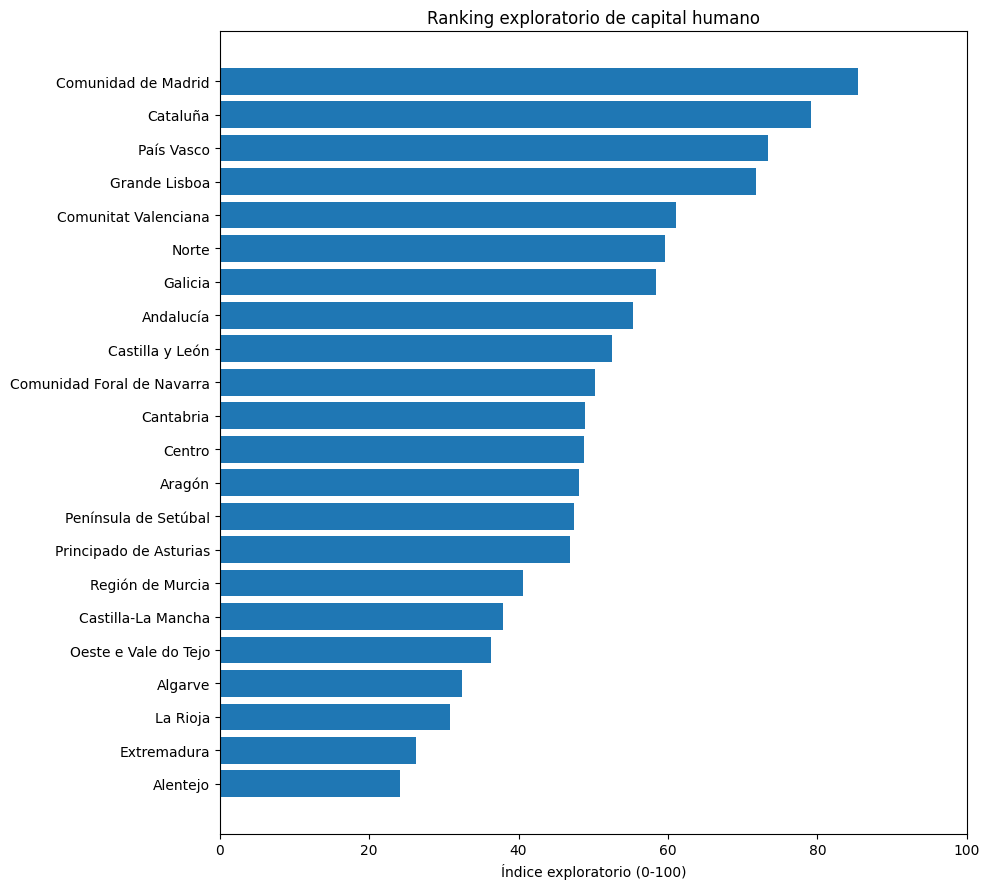

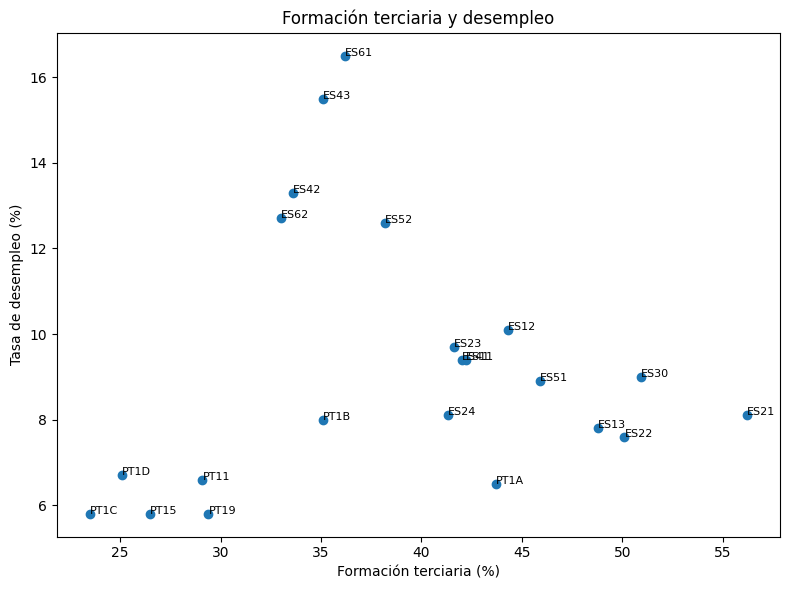

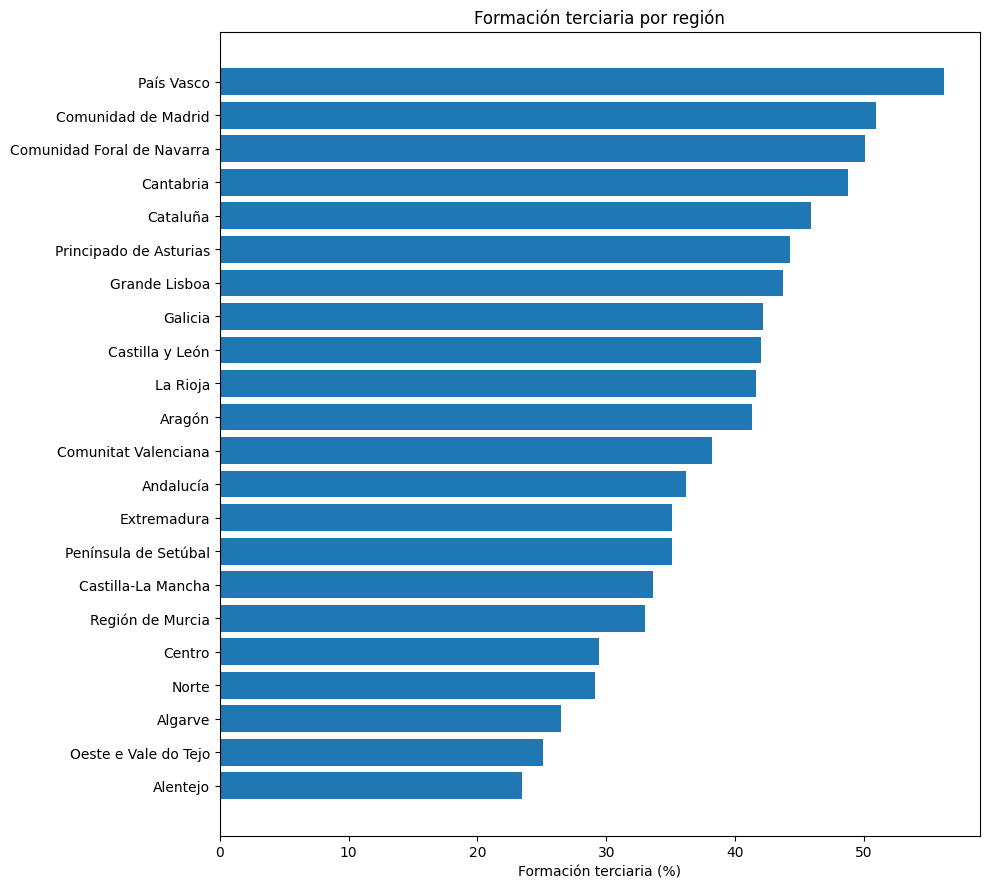

Figuras generadas: 3
Andorra aparece en el ranking: False
Estado 08A: correcto


In [13]:
# FIGURAS DEL ANÁLISIS EXPLORATORIO
df_figuras_08a = df_ranking_capital_humano_07a.copy()
figuras_08a = []

def guardar_figura(titulo, nombre):
    ruta = FIGURAS_DIR / nombre
    plt.tight_layout()
    plt.savefig(ruta, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    figuras_08a.append({
        "figura": titulo,
        "ruta": str(ruta),
        "existe": ruta.exists(),
    })

# Ranking exploratorio
datos = df_figuras_08a.sort_values(
    "indice_capital_humano_0_100"
)

plt.figure(figsize=(10, 9))
plt.barh(
    datos["nombre_territorio"],
    datos["indice_capital_humano_0_100"],
)
plt.xlim(0, 100)
plt.xlabel("Índice exploratorio (0-100)")
plt.title("Ranking exploratorio de capital humano")

guardar_figura(
    "Ranking exploratorio de capital humano",
    "figura_08A_categorias_capital_humano.png",
)

# Formación terciaria y desempleo
plt.figure(figsize=(8, 6))
plt.scatter(
    df_figuras_08a["nivel_formativo_terciario"],
    df_figuras_08a["tasa_desempleo"],
)

for _, fila in df_figuras_08a.iterrows():
    plt.annotate(
        fila["codigo_geo"],
        (
            fila["nivel_formativo_terciario"],
            fila["tasa_desempleo"],
        ),
        fontsize=8,
    )

plt.xlabel("Formación terciaria (%)")
plt.ylabel("Tasa de desempleo (%)")
plt.title("Formación terciaria y desempleo")

guardar_figura(
    "Formación terciaria y desempleo",
    "figura_08A_formacion_terciaria_vs_desempleo.png",
)

# Formación terciaria por región
datos = df_figuras_08a.sort_values(
    "nivel_formativo_terciario"
)

plt.figure(figsize=(10, 9))
plt.barh(
    datos["nombre_territorio"],
    datos["nivel_formativo_terciario"],
)
plt.xlabel("Formación terciaria (%)")
plt.title("Formación terciaria por región")

guardar_figura(
    "Formación terciaria por región",
    "figura_08A_formacion_terciaria_por_region.png",
)

# Inventario
df_figuras_generadas_08a = pd.DataFrame(figuras_08a)

df_figuras_generadas_08a.to_csv(
    MANIFEST_DIR / "inventario_figuras_notebook_08.csv",
    index=False,
    encoding="utf-8-sig",
)

andorra_en_ranking_08a = df_figuras_08a[
    "codigo_geo"
].eq("AD").any()

estado_08a = (
    "correcto"
    if len(df_figuras_generadas_08a) == 3
    and df_figuras_generadas_08a["existe"].all()
    and not andorra_en_ranking_08a
    else "revisar"
)

print("Figuras generadas:", len(df_figuras_generadas_08a))
print("Andorra aparece en el ranking:", andorra_en_ranking_08a)
print("Estado 08A:", estado_08a)

### Nota de interpretación

Las categorías muestran la posición relativa de las 22 regiones NUTS 2 comparables. No clasifican personas ni miden directamente la disponibilidad de técnicos o especialistas para centros de datos.

La formación terciaria se utiliza como indicador del contexto formativo territorial, pero incluye estudios superiores de cualquier área.

Andorra se mantiene como unidad nacional complementaria y queda fuera del ranking por su diferente escala territorial y su cobertura parcial.


## Dashboard del análisis exploratorio

Creamos un dashboard HTML con el ranking de las 22 regiones comparables, los pesos utilizados, las figuras y la interpretación del índice exploratorio.

El dashboard resume los resultados descriptivos del Notebook 08. No representa la selección final de ubicaciones ni la dimensión definitiva de Capital humano del IIT-CPD.


In [14]:
# DASHBOARD HTML DEL NOTEBOOK 08
import html

# Tablas
df_ranking_09a = df_ranking_capital_humano_07a[[
    "ranking_capital_humano",
    "codigo_geo",
    "nombre_territorio",
    "indice_capital_humano_0_100",
]].copy()
df_ranking_09a["indice_capital_humano_0_100"] = (
    df_ranking_09a["indice_capital_humano_0_100"].round(2)
)
df_ranking_09a.columns = [
    "Posición", "Código", "Región", "Índice exploratorio"
]
df_pesos_09a = df_pesos_07a.copy()
df_pesos_09a["score"] = (
    df_pesos_09a["score"]
    .str.replace("score_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Figuras
figuras_html_09a = []

for _, figura in df_figuras_generadas_08a.iterrows():
    ruta = Path(figura["ruta"])

    if ruta.exists():
        imagen = base64.b64encode(
            ruta.read_bytes()
        ).decode("utf-8")

        figuras_html_09a.append(
            f"<h2>{html.escape(figura['figura'])}</h2>"
            f'<img src="data:image/png;base64,{imagen}">'
        )

figuras_html_09a = "\n".join(figuras_html_09a)

# Dashboard
html_dashboard_09a = f"""
<html lang="es">
<head>
<meta charset="utf-8">
<title>Notebook 08 · Capital humano</title>
<style>
body {{font-family: Arial; max-width: 1100px; margin: auto; padding: 25px;}}
table {{border-collapse: collapse; width: 100%;}}
th, td {{padding: 7px; border-bottom: 1px solid #ddd;}}
img {{max-width: 100%;}}
.nota {{background: #f3f3f3; padding: 12px;}}
</style>
</head>

<body>
<h1>Notebook 08 · Análisis exploratorio de capital humano</h1>

<p>
Territorios totales: {len(df_modelo_socioeconomico_06a)} ·
Regiones comparables: {len(df_ranking_capital_humano_07a)}
</p>

<h2>Ranking exploratorio</h2>
{df_ranking_09a.to_html(index=False, border=0)}

<h2>Pesos utilizados</h2>
{df_pesos_09a.to_html(index=False, border=0)}

{figuras_html_09a}

<h2>Interpretación</h2>
<p>{html.escape(df_interpretacion_07b.iloc[0]["interpretacion"])}</p>

<div class="nota">
Este índice es exploratorio y no representa el IIT-CPD final.
Andorra se mantiene como unidad complementaria y fuera del ranking.
</div>
</body>
</html>
"""

# Guardado
ruta_dashboard_09a = (
    DASHBOARD_DIR
    / "dashboard_capital_humano_notebook_08.html"
)

ruta_dashboard_09a.write_text(
    html_dashboard_09a,
    encoding="utf-8",
)

estado_09a = (
    "correcto"
    if ruta_dashboard_09a.exists()
    and ruta_dashboard_09a.stat().st_size > 0
    else "revisar"
)

print("Dashboard:", ruta_dashboard_09a)
print("Estado 09A:", estado_09a)

Dashboard: /kaggle/working/08_demografia_laboral_capital_humano_iberia/dashboard/dashboard_capital_humano_notebook_08.html
Estado 09A: correcto


## Salidas finales y paquete ZIP del Notebook 08

Preparamos las salidas finales del Notebook 08 para su integración posterior y generamos el paquete ZIP.

La tabla completa conserva los indicadores originales y sus años de referencia para los 23 territorios. Para las 22 regiones NUTS 2 también se mantienen, como resultados exploratorios, el índice y el ranking calculados en este notebook.

Andorra la guardamos como unidad nacional complementaria, con cobertura parcial y fuera del ranking exploratorio.

El índice del Notebook 08 no constituye la dimensión final de Capital humano del IIT-CPD.

In [15]:
# SALIDAS PARA INTEGRACIÓN
scores_10a = [
    "ranking_capital_humano",
    *list(config_07a.keys()),
    "indice_capital_humano_0_1",
    "indice_capital_humano_0_100",
    "percentil_capital_humano",
    "categoria_capital_humano",
]

# Añadimos los resultados exploratorios
df_scores_10a = df_ranking_capital_humano_07a[
    ["codigo_geo", *scores_10a]
].copy()
df_capa_capital_humano_completa_10a = (
    df_modelo_socioeconomico_06a.merge(
        df_scores_10a,
        on="codigo_geo",
        how="left",
    )
)
df_capa_capital_humano_completa_10a[
    "bloque_modelo"
] = "capital_humano"
df_capa_capital_humano_completa_10a[
    "notebook_origen"
] = "Notebook 08"
df_capa_capital_humano_completa_10a[
    "descripcion_capa"
] = "Indicadores socioeconómicos y resultados exploratorios."
df_capa_capital_humano_completa_10a[
    "nota_integracion"
] = ""
df_capa_capital_humano_completa_10a.loc[
    ~df_capa_capital_humano_completa_10a["entra_ranking_nuts2"],
    "nota_integracion",
] = "Andorra es una unidad nacional complementaria."


# Separamos las salidas
df_capa_capital_humano_nuts2_10a = (
    df_capa_capital_humano_completa_10a[
        df_capa_capital_humano_completa_10a["entra_ranking_nuts2"]
    ].copy()
)
df_capa_capital_humano_andorra_10a = (
    df_capa_capital_humano_completa_10a[
        ~df_capa_capital_humano_completa_10a["entra_ranking_nuts2"]
    ].copy()
)

# Rutas que consume el Notebook 10
salidas_10a = {
    "capa_capital_humano_completa_para_modelo_master_notebook_08.csv":
        df_capa_capital_humano_completa_10a,

    "capa_capital_humano_nuts2_comparable_para_modelo_master_notebook_08.csv":
        df_capa_capital_humano_nuts2_10a,

    "capa_capital_humano_andorra_complementaria_para_modelo_master_notebook_08.csv":
        df_capa_capital_humano_andorra_10a,
}

for nombre, tabla in salidas_10a.items():
    tabla.to_csv(
        PROCESSED_DIR / nombre,
        index=False,
        encoding="utf-8-sig",
    )

# Control
control_10a = (
    len(df_capa_capital_humano_completa_10a)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08 + 1
    and len(df_capa_capital_humano_nuts2_10a)
    == N_TERRITORIOS_COMPARABLES_ESPERADOS_08
    and len(df_capa_capital_humano_andorra_10a) == 1
    and df_capa_capital_humano_completa_10a["codigo_geo"].is_unique
    and df_capa_capital_humano_nuts2_10a[
        INDICADORES_08
    ].notna().all().all()
)

if not control_10a:
    raise RuntimeError("Las salidas finales necesitan revisión.")

print("Capa completa:", len(df_capa_capital_humano_completa_10a))
print("Capa NUTS2:", len(df_capa_capital_humano_nuts2_10a))
print("Capa Andorra:", len(df_capa_capital_humano_andorra_10a))
print("Estado 10A: correcto")

Capa completa: 23
Capa NUTS2: 22
Capa Andorra: 1
Estado 10A: correcto


Validación final

Comprobamos que las capas finales existen, que tenemos 22 regiones NUTS 2 y Andorra como unidad complementaria, y que el ZIP se ha creado correctamente.

Si todos los controles son correctos, damos por finalizado el Notebook 08 y preparado para el Notebook 10.


In [16]:
# VALIDACIÓN FINAL Y ZIP
archivos_11a = {
    "processed/capa_capital_humano_completa_para_modelo_master_notebook_08.csv": 23,
    "processed/capa_capital_humano_nuts2_comparable_para_modelo_master_notebook_08.csv": 22,
    "processed/capa_capital_humano_andorra_complementaria_para_modelo_master_notebook_08.csv": 1,
}

# Comprobamos los tres CSV que necesita el Notebook 10
for archivo, filas_esperadas in archivos_11a.items():
    ruta = BASE_DIR / archivo

    if not ruta.exists():
        raise FileNotFoundError(f"Falta: {archivo}")

    df = pd.read_csv(ruta)

    if len(df) != filas_esperadas:
        raise RuntimeError(f"Filas incorrectas en: {archivo}")

    if df["codigo_geo"].duplicated().any():
        raise RuntimeError(f"codigo_geo duplicado en: {archivo}")

# Creamos el ZIP final
ZIP_FINAL_08 = (
    Path("/kaggle/working")
    / "notebook_08_capital_humano.zip"
)

with zipfile.ZipFile(
    ZIP_FINAL_08,
    "w",
    zipfile.ZIP_DEFLATED,
) as zip_ref:

    for ruta in BASE_DIR.rglob("*"):
        if ruta.is_file():
            zip_ref.write(
                ruta,
                ruta.relative_to(BASE_DIR),
            )

# Comprobamos el contenido del ZIP
with zipfile.ZipFile(ZIP_FINAL_08, "r") as zip_ref:
    contenido_zip_11a = zip_ref.namelist()

faltantes_11a = [
    archivo
    for archivo in archivos_11a
    if archivo not in contenido_zip_11a
]

if faltantes_11a:
    raise RuntimeError(
        f"Faltan archivos en el ZIP: {faltantes_11a}"
    )

print("CSV finales: 3/3 correctos")
print("Archivos en ZIP:", len(contenido_zip_11a))
print("ZIP final:", ZIP_FINAL_08)
print("Estado final: correcto")

CSV finales: 3/3 correctos
Archivos en ZIP: 46
ZIP final: /kaggle/working/notebook_08_capital_humano.zip
Estado final: correcto
